In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
img1 = cv2.imread('Assets/Bunga.png')
img2 = cv2.imread('Assets/Langit.png')
img3 = cv2.imread('Assets/Meledak.png')
img4 = cv2.imread('Assets/Windut.png')

# supaya warnanya keluar
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

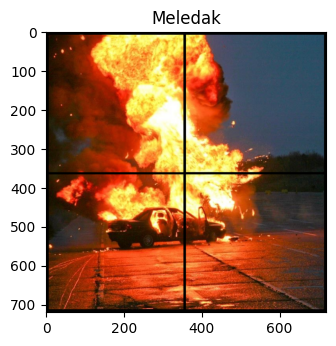

In [7]:
# menampilkan gambar
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img3)
plt.title("Meledak")

plt.show()

Text(0.5, 1.0, 'Part 4')

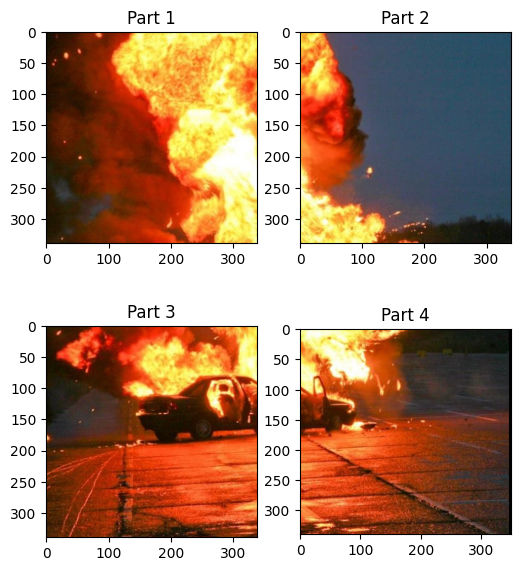

In [49]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

ctr1 = slice(img3, 10, 350, 'H')
ctr1 = slice(ctr1, 10, 350, 'V')

ctr2 = slice(img3, 10, 350, 'H')
ctr2 = slice(ctr2, 370, 710, 'V')

ctr3 = slice(img3, 370, 710, 'H')
ctr3 = slice(ctr3, 10, 350, 'V')

ctr4 = slice(img3, 370, 710, 'H')
ctr4 = slice(ctr4, 370, 720, 'V')

plt.figure(figsize=(6,7))

plt.subplot(2,2,1)
plt.imshow(ctr1, cmap="gray")
plt.title("Part 1")
plt.subplot(2,2,2)
plt.imshow(ctr2, cmap="gray")

plt.title("Part 2")
plt.subplot(2,2,3)
plt.imshow(ctr3, cmap="gray")
plt.title("Part 3")
plt.subplot(2,2,4)
plt.imshow(ctr4, cmap="gray")
plt.title("Part 4")


In [42]:
def ukuran_min(gambar):
    baris_min = min(len(citra) for citra in gambar)
    kolom_min = min(len(citra[0]) for citra in gambar)
    return baris_min, kolom_min

def potong(citra, tinggi, lebar):
    return [row[:lebar] for row in citra[:tinggi]]

def resize_semua(gambar):
    tinggi_min, lebar_min = ukuran_min(gambar)
    return [potong(citra, tinggi_min, lebar_min) for citra in gambar]

def ukuran_max(gambar):
    baris_max = max(len(citra) for citra in gambar)
    kolom_max = max(len(row) for citra in gambar for row in citra)
    return baris_max, kolom_max

def normalisasi(citra, baris_tujuan, kolom_tujuan):
    hasil = []
    for i in range(baris_tujuan):
        baris = []
        for j in range(kolom_tujuan):
            if i < len(citra) and j < len(citra[i]):
                baris.append(citra[i][j])
            else:
                baris.append(0)
        hasil.append(baris)
    return hasil

def gabung_2x2(citra1, citra2, citra3, citra4):
    citra1, citra2, citra3, citra4 = resize_semua([citra1, citra2, citra3, citra4])

    b, k = ukuran_max([citra1, citra2, citra3, citra4])
    i1 = normalisasi(citra1, b, k)
    i2 = normalisasi(citra2, b, k)
    i3 = normalisasi(citra3, b, k)
    i4 = normalisasi(citra4, b, k)

    gabung = []
    for i in range(b * 2):
        baris = []
        for j in range(k * 2):
            if i < b and j < k:
                baris.append(i1[i][j]) 
            elif i < b and j >= k:
                baris.append(i2[i][j - k]) 
            elif i >= b and j < k:
                baris.append(i3[i - b][j])
            else:
                baris.append(i4[i - b][j - k]) 
        gabung.append(baris)

    return gabung



Text(0.5, 1.0, 'Gabungan Meeledak')

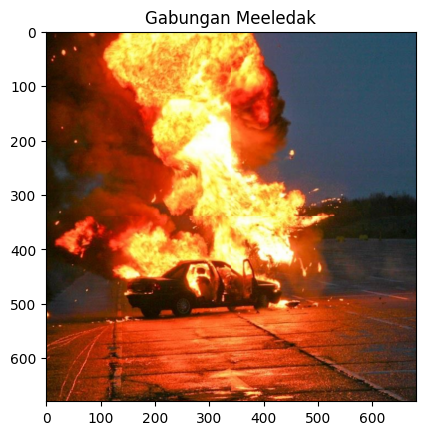

In [50]:
merge_meledak = gabung_2x2(ctr1, ctr2, ctr3, ctr4)

plt.imshow(merge_meledak)
plt.title("Gabungan Meeledak")

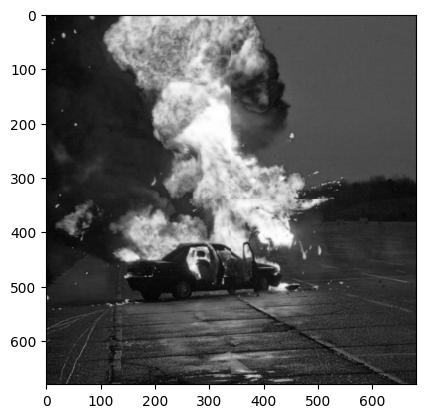

In [53]:
gray_merge = cv2.cvtColor(np.array(merge_meledak), cv2.COLOR_BGR2GRAY)

plt.imshow(gray_merge, cmap="gray")
plt.show()

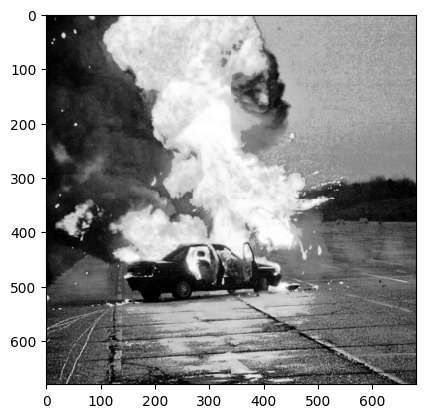

In [56]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # Hitung CDF dari index 1 sampai 255
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF ke rentang [0, 255]
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan CDF yang sudah dinormalisasi ke setiap pixel
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

# Cara memanggil:
# hasil_ekualisasi = ekualisasi(citra_kalian)

hasil_ekualisasi = ekualisasi(gray_merge)
plt.imshow(hasil_ekualisasi, cmap="gray")

In [65]:
# ====================================
# FUNGSI HISTOGRAM
# ====================================

def buat_histogram(citra):

    # histogram kosong
    hist = [0] * 256

    # ukuran gambar
    height, width = citra.shape

    # hitung jumlah pixel
    for i in range(height):
        for j in range(width):

            nilai_pixel = int(citra[i][j])

            hist[nilai_pixel] += 1

    return hist


# ====================================
# FUNGSI TAMPILKAN HISTOGRAM
# ====================================

def plot_histogram(histogram, title, warna):

    plt.bar(range(256), histogram, color=warna, width=1)

    plt.title(title)
    plt.xlabel("Intensitas Pixel")
    plt.ylabel("Jumlah Pixel")
    plt.xlim(0,255)

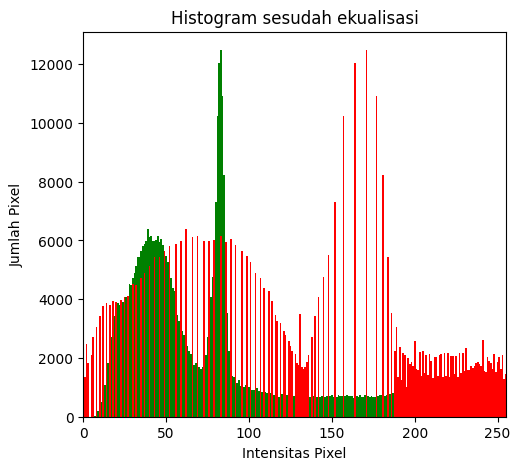

In [72]:
sebelum_eq = buat_histogram(gray_merge)
sesudah_eq = buat_histogram(hasil_ekualisasi)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_histogram(sebelum_eq, "Histogram sebelum ekualisasi", "green")
plot_histogram(sesudah_eq, "Histogram sesudah ekualisasi", "red")


In [51]:
def spesifikasi_histogram(citra_asal, citra_target):

    # ukuran citra asal
    height, width = citra_asal.shape

    # histogram kosong
    hist_asal = [0] * 256
    hist_target = [0] * 256

    # hitung histogram citra asal
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):

            pixel = int(citra_asal[i][j])

            hist_asal[pixel] += 1

    # hitung histogram citra target
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):

            pixel = int(citra_target[i][j])

            hist_target[pixel] += 1

    # buat CDF kosong
    cdf_asal = [0] * 256
    cdf_target = [0] * 256

    # isi nilai awal
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    # hitung CDF
    for i in range(1, 256):

        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]

        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    # normalisasi CDF
    cdf_asal = np.array(cdf_asal) / cdf_asal[-1]
    cdf_target = np.array(cdf_target) / cdf_target[-1]

    # array mapping
    map_hist = np.zeros(256, dtype=np.uint8)

    # cari mapping histogram
    for i in range(256):

        selisih = np.abs(cdf_target - cdf_asal[i])

        map_hist[i] = np.argmin(selisih)

    # array hasil
    hasil = np.zeros((height, width), dtype=np.uint8)

    # terapkan mapping
    for i in range(height):
        for j in range(width):

            pixel_lama = citra_asal[i][j]

            hasil[i][j] = map_hist[pixel_lama]

    return hasil

(720, 720)


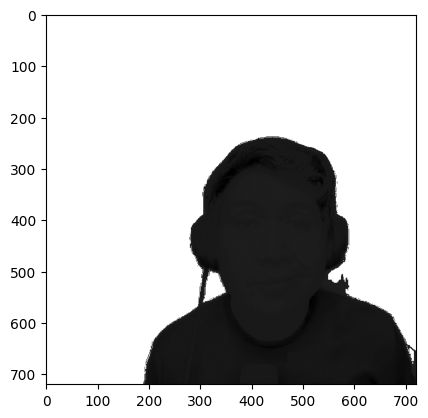

In [52]:
windut = cv2.imread("Assets/Windut.png")
bunga = cv2.imread("Assets/Bunga.png")

windut_gray = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)
bunga_gray = cv2.cvtColor(bunga, cv2.COLOR_BGR2GRAY)

windut_sp = spesifikasi_histogram(windut_gray, bunga_gray)
plt.imshow(windut_sp, cmap="gray")
print(windut_sp.shape)

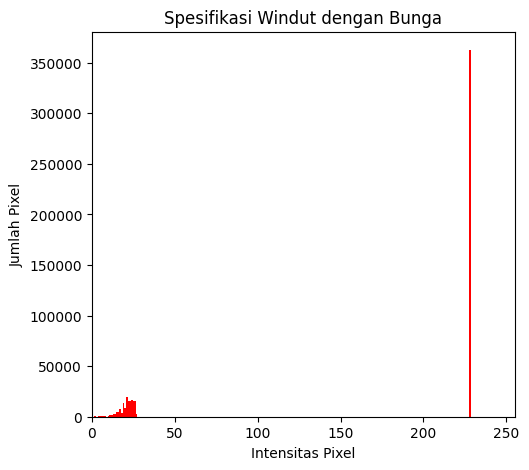

In [69]:
sebelum_eq = buat_histogram(windut_sp)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_histogram(sebelum_eq, "Spesifikasi Windut dengan Bunga", "red")

In [73]:
hasil = np.zeros_like(windut_sp, dtype=int) 
for i in range(hasil.shape[0]): 
    for j in range(hasil.shape[1]): 
        if(windut_sp[i,j]>50): 
            hasil[i,j] = gray_merge[i,j] 
plt.imshow(hasil, cmap="gray") 

IndexError: index 680 is out of bounds for axis 1 with size 680